# ECS659U - Coursework


* The **goal** of the CW is similar to that of Week 2's Lab: fitting a curve to data, also known as **curve fitting**.
* This has applications in many different disciplines that make use of AI: FinTech, Physics Modelling, or even Sports.
* For example, we might be interested in learning the evolution (over time) of the price of a specific product in different countries. This can depend on several factors: the product itself, the country, the initial value of the product's price, etc.
* As usual, we are interested in learning a model that finds these relationships *from the data*.


## Learning a set of functions

* The main difference with Week 2's Lab that we will train a network that does not learn a single function but a set of functions.
* You are provivided with a training set ("train_data.csv") containing 30,000 functions. Each function has $100$ points (N_x = 100) on the x-axis from a $[-1, 1]$ distribution.
* Because we are dealing with a family of functions and not just a single function, our model must be able to perform two tasks: *Function Selection* and *Regression*.
* Function selection means that given some *additional* input (to be defined below) the model somehow must choose which function from the set of functions it needs to model.
* Once the correct function is picked then the model must perform regression i.e. learn the input-output relationship $y=f_a(x)$ where $f_a$ is the selected function.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CW

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/CW


In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

y_train = np.loadtxt('train_data.csv', delimiter=',')
N_train, Nx = y_train.shape
x_train = np.tile(np.linspace(-1, 1, Nx), (N_train, 1))
x_tensor = torch.from_numpy(x_train).float()
y_tensor = torch.from_numpy(y_train).float()
train_loader = DataLoader(TensorDataset(x_tensor, y_tensor),batch_size=128,shuffle=True)

y_test = torch.from_numpy(np.loadtxt('test_data.csv', delimiter=',')).float()
x_test = torch.linspace(-1, 1, 100).unsqueeze(0).repeat(300, 1)

# Load the context bundle
test_contexts = torch.load('test_observations.pt')


## The Learning Objective


* For both *training and testing*, a random subset of $N$ pairs $(x_o, y_o)$ (which is called observed data) is provided. This acts as prior information to help the model identify which specific function is looking at.

* The model will take the observed pairs $(x_o, y_o)$ and target values $x_t$ and will produce the estimated values $\hat{y}_t$. The ultimate goal is to estimate the function corresponding to the curve that observed pairs $(x_o, y_o)$ belong to and then estimate the output value $\hat{y}_t$ corresponding to $x_t$. During training we have access to the ground-truth values $y_t$, and thus we can compute a loss between the model's predictions $\hat{y}_t$ and the ground-truth values $y_t$.  


## The Model Architecture

* Our model consists of 2 MLPs which must be jointly trained. Specifically, you should implement the following architecture:
* *Encoder*: The first MLP is called the Encoder. It takes as input the random set of $N$ observed pairs $(x_o, y_o)$  and maps each of them (through a series of hidden layers) to a feature vector of dimension $h_{dim}$. A final layer produces the latent feature representation $r_o$ of dimension $r_{dim}$.
* A total observed feature is produced by summing or averaging over all features (e.g., $r_O=\frac{1}{N}\sum_o r_o$).
* *Decoder*: The second MLP is called the Decoder. It takes as input the $r_O$ and each input data $x_t$. The Decoder (through a series of hidden layers) maps the pair $(r_O, x_t)$ to some feature vector of dimension $h_{dim}$. A final layer will produce the model's prediction $\hat{y}_t$ (corresponding to the input $x_t$).
* Hint! Try different choices for the number of hidden layers in the MLPs and for the hidden dimension $h_{dim}$.


## Tasks

* You have to implement the following:
    1. Create the model based on the provided architecture description. $r_{dim}$ should be a configurable hyperparameter. (20%)
    2. Create the optimizer and the loss function. Write the training script that will train the model and print the training loss. (20%)
    3. Train three versions of the model, called model2, model4, model8, by only alternating the dimension of the latent representation $r_{dim}$ to be 2, 4, and 8, respectively. Using the provided test_data.csv and the observation pairs provided in test_observations.pt, calculate the average error for each model. Provide results for all these calculations in your report. (30%)
    4.  Given you results, which latent representation ( $r_{dim}$ ) yielded the best results and which latent representation ($r_{dim}$) offered the  most significant improvement? How many independent variables were used to generate the training and test data? Provide explanation. (20%)
    5. For $r_{dim}$ which offered the most improvement, how capable your model was in terms of disentagling the independent variables? Hint: check the correlations between the dimensions of the latent representation. Provide explanation. (10%)

# Notes
**xi yi** Training examples, input and output of a function

**Latent Representation**
Shows information about function, like slope, intercept

**Latent Vector Size**
r_dim - if its 2 then the vector has 2 numbers in it - [0.2, 0.3]

**Encoder output**
example take mean(all ri), output single r,

decoder will use this to predict new y value. ri = encoder(xi, yi)

In [3]:
# Imports
from torch import nn

In [4]:
# Helper function for weights
def init_weights(m):
  if isinstance(m, nn.Linear):
    torch.nn.init.normal_(m.weight, std=0.01)
    torch.nn.init.zeros_(m.bias)

The below MLP class will make every mlp have 2 hidden layers

Each hidden layer will have 64 neurons

After each hidden layer, the relu funciton will be applied to the output

In [5]:
# MLP Classx

class Net(torch.nn.Module):
  def __init__(self, num_inputs, num_outputs):
    super(Net, self).__init__()
    self.num_inputs = num_inputs
    self.num_outputs = num_outputs
    num_hidden = 64

    self.Linear1 = nn.Linear(num_inputs, num_hidden)
    self.Linear2 = nn.Linear(num_hidden, num_hidden)
    self.Linear3 = nn.Linear(num_hidden, num_outputs)

  def forward(self, x):
    out = torch.relu(self.Linear1(x))
    out = torch.relu(self.Linear2(out))
    out = self.Linear3(out)
    return out



# Implement the encoder and decoder MLPs
*   Each should have configurable number of input and output dimensions

**Encoder**
Transforms the input data to a latent output vector for the decoder to use
1.   Takes context set as input: xi yi pairs
2.   Maps each pair to a latent representation vector ri
3.   Take average of representations to show single context representation


**Decoder**
Uses latent representation of the data, and the new input that we want a prediction for

In [6]:
class CombinedModel(nn.Module):
  def __init__(self, x_dim, y_dim, r_dim):
    super().__init__()

    # Encoder
    self.encoder = Net(
        num_inputs = x_dim + y_dim,
        num_outputs = r_dim
    )

    # Decoder
    self.decoder = Net(
        num_inputs = x_dim + r_dim,
        num_outputs = y_dim
    )

  def forward(self, x_context, y_context, x_target):
    # Concatenate the columns of x and y, for each context point
    # Shape - [batch size, n context, x dim + y dim]
    # Number of rows stay the same, the columns were just added together
    xy = torch.cat([x_context, y_context], dim=-1)

    # We calculate rows of r_i, and take the average
    # We want one value per column for the aggregated r vector
    r_i = self.encoder(xy)

    # So average accross context point dimension
    # Gives one latent vector per function
    r = torch.mean(r_i, dim=1)

    # Repeat each function representation across all target points
    r = r.unsqueeze(1)
    r = r.repeat(1, x_target.shape[1], 1)

    # Put the x values together with the r values,
    # x defines where we want to evaluate the function
    # r values are describing the function
    decoder_input = torch.cat([x_target, r], dim=-1)
    y_pred = self.decoder(decoder_input)

    return y_pred

# Setting up the training process

**Optimiser**
Set up optimiser, using SGD (Stoachastic Gradient Descent) with learning rate and weight decay

**Loss Function**
Measure difference between true outputs and predicted outputs. Use MSE or Cross Entropy Loss

**Training Loop**
*   Each iteration, sample a function from training set.
*   Split observations
*   Context set: observed points used to infer function
*   Target set: points the model must predict
*   Pass (x, y) through encoder
*   Produce ri, and compute the aggregated mean
*   Decode predictions, combine r with target prediction xt
*   Compute loss with the predicted y hat t with true yt
*   Backpropagation, compute gradients and optimiser update network weights



In [7]:
def train_model(model, train_loader, epochs, learning_rate):
  wd = 0
  optimiser = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=wd)
  loss_f = nn.MSELoss()

  model.train()

  losses_arr = []

  for epoch in range(epochs):

    epoch_loss = 0

    for x_batch, y_batch in train_loader:

      # Ensure the points are treated as 1D input/output
      x_batch = x_batch.unsqueeze(-1)
      y_batch = y_batch.unsqueeze(-1)

      # Use first n as the context points
      n_context = 10
      x_c = x_batch[:, :n_context, :]
      y_c = y_batch[:, :n_context, :]
      # Use all points as targets


      # Ensure the gradients from previous step are cleared
      # so that only the current batch contributes to the update
      optimiser.zero_grad()

      # Model predicts target y values from the context set and target x values
      # Compare the predictions with the true target y values
      y_pred = model(x_c, y_c, x_batch)
      loss = loss_f(y_pred, y_batch)

      loss.backward()
      optimiser.step()

      epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print("Epoch:", epoch, "Total Loss:", epoch_loss, "Avg Loss:", avg_loss)
    losses_arr.append(avg_loss)

  return losses_arr

Initialise model, train,

In [8]:
model_2 = CombinedModel(x_dim=1, y_dim=1, r_dim=2)
arr_2 = train_model(model_2, train_loader, epochs=50, learning_rate = 0.01)

Epoch: 0 Total Loss: 120.65964403748512 Avg Loss: 0.5134452937765325
Epoch: 1 Total Loss: 86.04389876127243 Avg Loss: 0.3661442500479678
Epoch: 2 Total Loss: 80.18847292661667 Avg Loss: 0.34122754436858155
Epoch: 3 Total Loss: 78.05199879407883 Avg Loss: 0.3321361650811865
Epoch: 4 Total Loss: 77.16905742883682 Avg Loss: 0.32837896778228437
Epoch: 5 Total Loss: 76.42416840791702 Avg Loss: 0.325209227267732
Epoch: 6 Total Loss: 75.95631970465183 Avg Loss: 0.3232183817219227
Epoch: 7 Total Loss: 75.6875322908163 Avg Loss: 0.32207460549283534
Epoch: 8 Total Loss: 75.46429051458836 Avg Loss: 0.32112464048761
Epoch: 9 Total Loss: 75.28655774891376 Avg Loss: 0.32036833084644156
Epoch: 10 Total Loss: 75.0338622033596 Avg Loss: 0.31929303065259407
Epoch: 11 Total Loss: 75.0103375017643 Avg Loss: 0.3191929255394225
Epoch: 12 Total Loss: 74.79727731645107 Avg Loss: 0.3182862864529833
Epoch: 13 Total Loss: 74.69375863671303 Avg Loss: 0.3178457814328214
Epoch: 14 Total Loss: 74.65350699424744 Avg 

In [14]:
model_4 = CombinedModel(x_dim=1, y_dim=1, r_dim=4)
arr_4 = train_model(model_4, train_loader, epochs=50, learning_rate = 0.01)

Epoch: 0 Total Loss: 131.69110518693924 Avg Loss: 0.56038768164655
Epoch: 1 Total Loss: 109.3142900466919 Avg Loss: 0.4651671916880506
Epoch: 2 Total Loss: 84.4533714056015 Avg Loss: 0.35937604853447447
Epoch: 3 Total Loss: 80.27545601129532 Avg Loss: 0.34159768515444816
Epoch: 4 Total Loss: 78.31623339653015 Avg Loss: 0.33326056764480916
Epoch: 5 Total Loss: 77.31487013399601 Avg Loss: 0.3289994473787064
Epoch: 6 Total Loss: 76.74455636739731 Avg Loss: 0.32657258028679703
Epoch: 7 Total Loss: 76.37675562500954 Avg Loss: 0.3250074707447214
Epoch: 8 Total Loss: 76.03619262576103 Avg Loss: 0.3235582664926001
Epoch: 9 Total Loss: 75.76320424675941 Avg Loss: 0.3223966138159975
Epoch: 10 Total Loss: 75.54215990006924 Avg Loss: 0.32145599957476273
Epoch: 11 Total Loss: 75.33219115436077 Avg Loss: 0.3205625155504714
Epoch: 12 Total Loss: 75.12092140316963 Avg Loss: 0.3196634953326367
Epoch: 13 Total Loss: 75.01465958356857 Avg Loss: 0.31921131737688757
Epoch: 14 Total Loss: 74.82732005417347 

In [15]:
model_8 = CombinedModel(x_dim=1, y_dim=1, r_dim=8)
arr_8 = train_model(model_8, train_loader, epochs=50, learning_rate = 0.01)

Epoch: 0 Total Loss: 125.18810698390007 Avg Loss: 0.5327153488676599
Epoch: 1 Total Loss: 91.56221070885658 Avg Loss: 0.3896264285483259
Epoch: 2 Total Loss: 83.25750663876534 Avg Loss: 0.3542872622926184
Epoch: 3 Total Loss: 80.2342963218689 Avg Loss: 0.3414225375398676
Epoch: 4 Total Loss: 78.36831521987915 Avg Loss: 0.33348219242501764
Epoch: 5 Total Loss: 77.23131087422371 Avg Loss: 0.3286438760605264
Epoch: 6 Total Loss: 76.63355413079262 Avg Loss: 0.32610023034379837
Epoch: 7 Total Loss: 76.27242678403854 Avg Loss: 0.3245635182299513
Epoch: 8 Total Loss: 75.91764920949936 Avg Loss: 0.3230538264234015
Epoch: 9 Total Loss: 75.63685865700245 Avg Loss: 0.32185897300852107
Epoch: 10 Total Loss: 75.48210695385933 Avg Loss: 0.32120045512280565
Epoch: 11 Total Loss: 75.26631985604763 Avg Loss: 0.3202822121533942
Epoch: 12 Total Loss: 75.15822595357895 Avg Loss: 0.31982223810033594
Epoch: 13 Total Loss: 75.01394082605839 Avg Loss: 0.319208258834291
Epoch: 14 Total Loss: 74.85061340034008 

Text(0, 0.5, 'Loss')

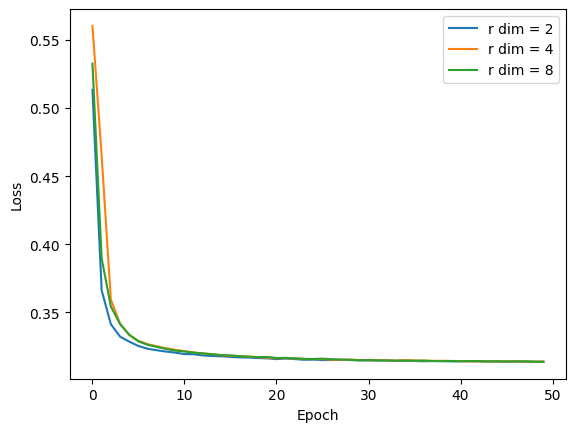

In [16]:
import matplotlib.pyplot as plt
plt.plot(arr_2, label = 'r dim = 2')
plt.plot(arr_4, label = 'r dim = 4')
plt.plot(arr_8, label = 'r dim = 8')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")

Text(0.5, 1.0, 'Training Loss (Zoomed)')

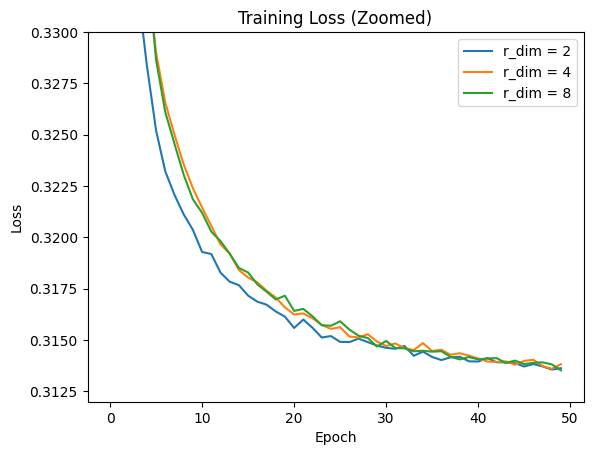

In [21]:
plt.figure()
plt.plot(arr_2, label="r_dim = 2")
plt.plot(arr_4, label="r_dim = 4")
plt.plot(arr_8, label="r_dim = 8")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim(0.312, 0.330)
plt.legend()
plt.title("Training Loss (Zoomed)")